In [169]:
import torch, torchvision
import numpy as np 
import cv2
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
import sys
import pytorch_lightning as pl

In [170]:
FAR_Height = 640
FAR_Width = 480
BASE_DIR = os.getcwd()
FAR_MP3D_DIR = f"{BASE_DIR}/far/mp3d_loftr"
sys.path.append(FAR_MP3D_DIR)

from src.lightning.lightning_loftr import PL_LoFTR
sys.path.append(f"{FAR_MP3D_DIR}/third_party/prior_ransac")



imgA_path = f"{BASE_DIR}/imgA.JPG"
imgB_path = f"{BASE_DIR}/imgB.JPG"

## Image Preparation
Here we'll write a function that prepares the image to be fed into the FAR model

In [171]:
def load_image_for_far(path, device="cpu"):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found at path: {path}")
    img = cv2.resize(img, (FAR_Width, FAR_Height)) # Note for self: cv2 uses (width, height) but numpy uses (height, width), and output of resize is (FAR_Height, FAR_Width)
    img = img.astype(np.float32) / 255.0 # Normalizing the image to [0, 1], shape: (FAR_Height, FAR_Width)
    img_tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device) # Shape: (1, 1, FAR_Height, FAR_Width)
    return img_tensor

*Reading The Images Into Tensors*

In [172]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fx = fy = 517.97 #LoFTR default focal length
cx = 320
cy = 240

K = np.array([
    [fx, 0,  cx],
    [0,  fy, cy],
    [0,  0,   1]
], dtype=np.float32)

# Converting K to torch tensor and Adding batch dimension here
K0 = torch.from_numpy(K).unsqueeze(0)
K1 = torch.from_numpy(K).unsqueeze(0)

imgA = load_image_for_far(imgA_path, device)
imgB = load_image_for_far(imgB_path, device)

batch = {
    "image0": imgA,
    "image1": imgB,
    "K0": K0,
    "K1": K1,
    "depth0": torch.zeros_like(imgA), # dummy depth maps assigned as zeros
    "depth1": torch.zeros_like(imgB), # same
    "dataset_name": ["mp3d"],
    "scene_id": torch.tensor([0]), # dummy scene id
    "pair_id": torch.tensor([0]) # dummy pair id
}
    

## Pose Estimation From Pretrained Model

In [173]:
from src.config.default import get_cfg_defaults

data_cfg = f"{BASE_DIR}/far/mp3d_loftr/configs/data/mp3d.py"
model_cfg = f"{BASE_DIR}/far/mp3d_loftr/configs/loftr/indoor/loftr_ds_dense.py"

# merging data and model configs
config = get_cfg_defaults()
config.merge_from_file(model_cfg)
config.merge_from_file(data_cfg)
config.set_new_allowed(True)

config.LOFTR.FEAT_SIZE = 128
config.LOFTR.NUM_ENCODER_LAYERS = 6
config.LOFTR.NUM_BANDS = 10
config.LOFTR.CORRESPONDENCE_TRANSFORMER_USE_POS_ENCODING = False
config.LOFTR.CORRESPONDENCE_TF_USE_GLOBAL_AVG_POOLING = False
config.LOFTR.CORRESPONDENCE_TF_USE_FEATS = False
config.LOFTR.CTF_CAT_FEATS = False
config.LOFTR.NUM_HEADS = 8
config.USE_PRED_CORR = False
config.STRICT_FALSE = False
config.EVAL_FIT_ONLY = False

config.LOFTR.PREDICT_TRANSLATION_SCALE = False
config.LOFTR.REGRESS_RT = True
config.LOFTR.REGRESS_LOFTR_LAYERS = 1
config.LOFTR.REGRESS.USE_POS_EMBEDDING = True
config.LOFTR.REGRESS.REGRESS_USE_NUM_CORRES = True
config.LOFTR.COARSE.LAYER_NAMES = ['self', 'cross'] * 3
config.LOFTR.FROM_SAVED_PREDS = None
config.LOFTR.SOLVER = "prior_ransac"
config.LOFTR.USE_MANY_RANSAC_THR = True
config.LOFTR.FINE_PRED_STEPS = 2
config.LOFTR.REGRESS.SAVE_MLP_FEATS = False
config.LOFTR.REGRESS.USE_SIMPLE_MOE = True
config.LOFTR.REGRESS.USE_2WT = True
config.LOFTR.REGRESS.USE_5050_WEIGHT = False
config.LOFTR.REGRESS.USE_1WT = False
config.LOFTR.REGRESS.SCALE_8PT = True
config.LOFTR.REGRESS.SAVE_GATING_WEIGHTS = False
config.LOFTR.TRAINING = False

config.LOAD_PREDICTIONS_PATH = None
config.EXP_NAME = "far_mp3d_loftr_experiment"
config.USE_CORRESPONDENCE_TRANSFORMER = False
config.CORRESPONDENCES_USE_FIT_ONLY = False
config.EVAL_SPLIT = "test"
config.PL_VERSION = pl.__version__

model = PL_LoFTR(config, pretrained_ckpt=f"{BASE_DIR}/far/mp3d_loftr/pretrained_models/far_8pt.ckpt", split="test").to(device)
model.eval()

for k in batch:
    if isinstance(batch[k], torch.Tensor):
        batch[k] = batch[k].to(device)

with torch.no_grad():
    _ = model.test_step(batch, batch_idx=0, skip_eval=True)

pose_mat = batch["loftr_rt"].cpu().numpy() # Shape: (4, 4)
print("Estimated Pose Matrix (4x4):")
print(pose_mat)

using num correspondence? 4


2025-12-08 04:54:49.976 | INFO     | src.lightning.lightning_loftr:__init__:76 - Load '/home/isty/MM803_Assignment1/far/mp3d_loftr/pretrained_models/far_8pt.ckpt' as pretrained checkpoint


Estimated Pose Matrix (4x4):
[[ 0.92019873 -0.03311502 -0.39004831  0.6814067 ]
 [ 0.05070008  0.99810492  0.03487231  0.20334117]
 [ 0.38815434 -0.05186494  0.92013381  0.70309123]]


### Getting Rotation and Translation Vector

In [174]:
def get_R_t_from_pose(batch):

    pose_mat = batch["loftr_rt"]
    pose_np = pose_mat.detach().cpu().numpy()

    # Just in case batch dimension is present
    if pose_np.ndim == 3:
        pose_np = pose_np[0]

    if pose_np.shape == (4, 4):
        pose_np = pose_np[:3, :]

    R = pose_np[:, :3]
    t = pose_np[:, 3]
    return R, t


## Preparing Images For Warping

In [175]:
import math

def make_intrinsics(w, h, hfov_deg=60.0):
    '''
    Camera Intrinsics using horizontal field of view (hfov_deg).
    fx ≈ fy, principal point is centered.
    '''
    fx = (w / 2) / math.tan(math.radians(hfov_deg) / 2)
    fy = fx
    cx = w / 2.0
    cy = h / 2.0

    K = np.array([
        [fx, 0,  cx],
        [0,  fy, cy],
        [0,  0,  1]
    ], dtype=np.float32)

    return K

def cylindrical_projection(img, K):
    '''
    Project image onto a cylinder using intrinsics K.
    '''
    h, w = img.shape[:2]
    fx = K[0, 0]
    fy = K[1, 1]
    cx = K[0, 2]
    cy = K[1, 2]

    # pixel grid
    xs = np.arange(w)
    ys = np.arange(h)
    xx, yy = np.meshgrid(xs, ys)

    # normalized camera coordinates
    x_norm = (xx - cx) / fx
    y_norm = (yy - cy) / fy

    # cylindrical projection
    theta = np.arctan(x_norm)
    h_ = y_norm / np.sqrt(1 + x_norm**2)

    # mapping back to pixel space
    x_cyl = fx * theta + cx
    y_cyl = fy * h_ + cy

    map_x = x_cyl.astype(np.float32)
    map_y = y_cyl.astype(np.float32)

    cyl = cv2.remap(
        img, map_x, map_y,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )
    return cyl


In [176]:
img_ref = cv2.imread(imgA_path)
img_tgt = cv2.imread(imgB_path)

if img_ref is None or img_tgt is None:
    raise FileNotFoundError("One of the images could not be loaded. Check the image paths.")

STITCH_W = 1000
STITCH_H = 665

img_ref = cv2.resize(img_ref, (STITCH_W, STITCH_H))
# img_ref = cv2.resize(img_ref)
img_tgt = cv2.resize(img_tgt, (STITCH_W, STITCH_H))
# img_tgt = cv2.resize(img_tgt)


K0 = make_intrinsics(STITCH_W, STITCH_H)
K1 = make_intrinsics(STITCH_W, STITCH_H)

img_ref_cyl = cylindrical_projection(img_ref, K0)
img_tgt_cyl = cylindrical_projection(img_tgt, K1)


In [177]:

def homography_from_R_t(K0, K1, R, t, n=None, d=1.0):
    '''
    Computing homography H from R, t, intrinsics K0, K1
    '''
    # the intrinsics
    K0 = np.asarray(K0, dtype=np.float32).reshape(3, 3)
    K1 = np.asarray(K1, dtype=np.float32).reshape(3, 3)
    K1_inv = np.linalg.inv(K1)

    # rotation
    R = np.asarray(R, dtype=np.float32)
    if R.ndim == 3:
        # if batched, take first
        R = R[0]
    R = R.reshape(3, 3)

    # translation
    t = np.asarray(t, dtype=np.float32)
    if t.ndim == 2 and t.shape[0] == 1:
        t = t[0]          # (1,3) -> (3,)
    t = t.reshape(3, 1)    # (3,1)

    # plane normal
    if n is None:
        n = np.array([0, 0, 1], dtype=np.float32)
    else:
        n = np.asarray(n, dtype=np.float32)
    n = n.reshape(3, 1)    # (3,1)

    # plane-induced homography in camera coordinates
    # t n^T / d  -> (3,1) @ (1,3) = (3,3)
    tnT_over_d = (t @ n.T) / float(d)
    M = R - tnT_over_d      # (3,3)

    # pixel-space homography
    H = K0 @ M @ K1_inv     # (3,3)

    # normalize
    if H[2, 2] != 0:
        H = H / H[2, 2]

    return H


def warp_to_panorama(img_ref, img_tgt, H):
    '''
    Warp target image into reference frame using homography H (tgt -> ref),
    and build a panorama canvas large enough to hold both views.
    '''
    h, w = img_ref.shape[:2]

    # corners of reference image (in ref coords)
    ref_corners = np.array([
        [0, 0],
        [w, 0],
        [w, h],
        [0, h]
    ], dtype=np.float32).reshape(-1, 1, 2)

    # corners of target image, warped into ref coords
    tgt_corners = cv2.perspectiveTransform(ref_corners, H)  # we reuse same 4 corners shape

    # stacking both sets and find overall bounds
    all_corners = np.vstack((ref_corners, tgt_corners))

    xmin, ymin = np.int32(all_corners.min(axis=0).ravel() - 20)  # small margin
    xmax, ymax = np.int32(all_corners.max(axis=0).ravel() + 20)

    pano_w = xmax - xmin
    pano_h = ymax - ymin

    # shifting so that xmin,ymin maps to (0,0)
    shift = np.array([
        [1.0, 0.0, -xmin],
        [0.0, 1.0, -ymin],
        [0.0, 0.0,  1.0]
    ], dtype=np.float32)

    # warping target with shifted homography
    H_canvas = shift @ H
    pano_tgt = cv2.warpPerspective(img_tgt, H_canvas, (pano_w, pano_h))

    # placing reference image on same canvas using pure shift
    pano_ref = np.zeros_like(pano_tgt)
    pano_ref = cv2.warpPerspective(img_ref, shift, (pano_w, pano_h))

    return pano_ref, pano_tgt

R, t = get_R_t_from_pose(batch)
H_stitch = homography_from_R_t(K0, K1, R, t, n=None, d=10000.0)
H_stitch = np.linalg.inv(H_stitch)

pano_ref, pano_tgt = warp_to_panorama(img_ref_cyl, img_tgt_cyl, H_stitch)

## Blending

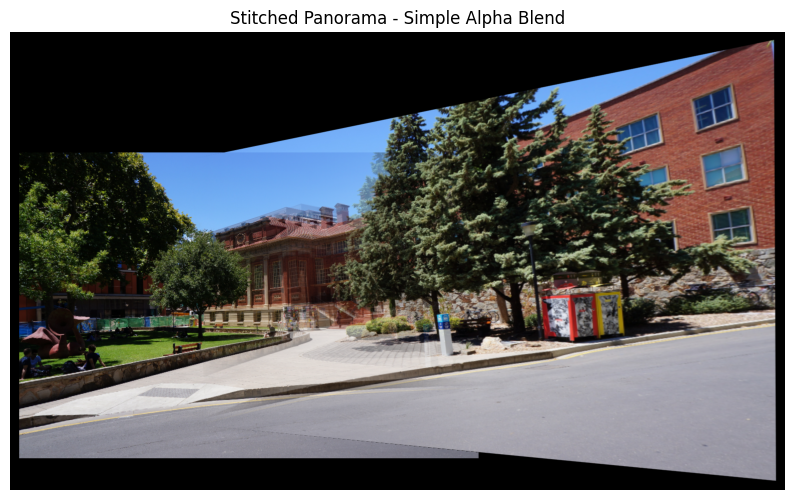

In [178]:
def simple_alpha_blend(pano_ref, pano_tgt):
    """
    Simple alpha blending between pano_ref and pano_tgt.
    Both must be same size (H, W, 3).
    """
    pano_ref_f = pano_ref.astype(np.float32)
    pano_tgt_f = pano_tgt.astype(np.float32)

    h, w = pano_ref.shape[:2]

    # Building masks where each image has valid content (non-zero pixels)
    mask_ref = np.any(pano_ref > 0, axis=2).astype(np.float32)  # (H, W)
    mask_tgt = np.any(pano_tgt > 0, axis=2).astype(np.float32)  # (H, W)

    # Regions where both exist
    overlap = (mask_ref * mask_tgt) > 0

    # Starting from simple "take max" compositing
    blended = np.where(mask_ref[..., None] > 0, pano_ref_f, pano_tgt_f)

    # If no overlap
    if not np.any(overlap):
        return blended.astype(np.uint8)

    # Finding overlap columns to build linear ramp horizontally
    cols = np.where(np.any(overlap, axis=0))[0]
    left_col, right_col = cols[0], cols[-1]

    # Avoiding division by zero if overlap is only one column
    if right_col == left_col:
        return blended.astype(np.uint8)

    # Building horizontal weight for target image across overlap columns
    x = np.arange(w, dtype=np.float32)
    w_tgt = (x - left_col) / float(right_col - left_col)
    w_tgt = np.clip(w_tgt, 0.0, 1.0)        # (W,)
    w_tgt_2d = np.tile(w_tgt, (h, 1))       # (H, W)
    w_ref_2d = 1.0 - w_tgt_2d               # (H, W)

    # Only blending where both images exist; elsewhere keep whichever is present
    # Expanding to 3 channels
    w_ref_3d = w_ref_2d[..., None]
    w_tgt_3d = w_tgt_2d[..., None]

    blended_f = np.zeros_like(pano_ref_f)

    # Only reference
    only_ref = (mask_ref > 0) & (mask_tgt == 0)
    blended_f[only_ref] = pano_ref_f[only_ref]

    # Only target
    only_tgt = (mask_tgt > 0) & (mask_ref == 0)
    blended_f[only_tgt] = pano_tgt_f[only_tgt]

    # Overlap: linear blend
    both = (mask_ref > 0) & (mask_tgt > 0)
    blended_f[both] = (w_ref_3d[both] * pano_ref_f[both] +
                       w_tgt_3d[both] * pano_tgt_f[both])

    return np.clip(blended_f, 0, 255).astype(np.uint8)

pano_simple = simple_alpha_blend(pano_ref, pano_tgt)
cv2.imwrite("stitched_simple.png", pano_simple)
def display_image(img, title="Image"):
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()
    
display_image(pano_simple, title="Stitched Panorama - Simple Alpha Blend")

## Multi-band Blending

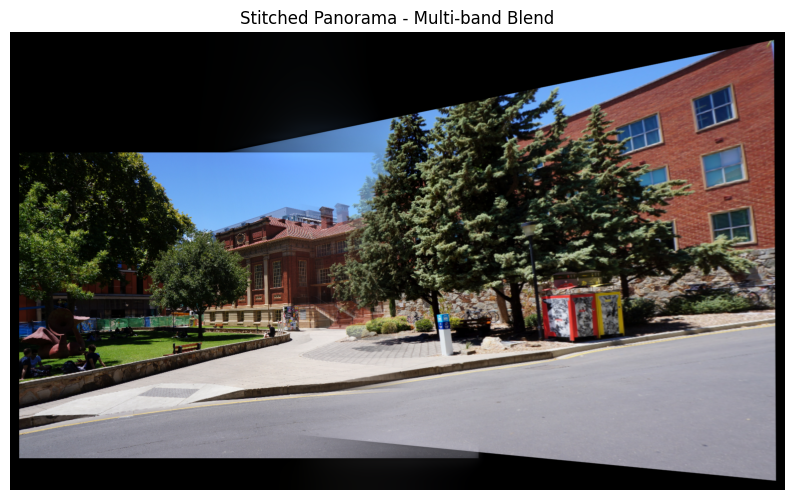

In [180]:
def build_gaussian_pyramid(img, levels):
    gp = [img.astype(np.float32)]
    for _ in range(levels - 1):
        img = cv2.pyrDown(img)
        gp.append(img.astype(np.float32))
    return gp

def build_laplacian_pyramid(gp):
    lp = []
    for i in range(len(gp) - 1):
        size = (gp[i].shape[1], gp[i].shape[0])
        GE = cv2.pyrUp(gp[i+1], dstsize=size)
        L = gp[i] - GE
        lp.append(L)
    lp.append(gp[-1])
    return lp

def multi_band_blend(pano_ref, pano_tgt, levels=5,
                     seam_offset=40, seam_width=260):
    """
    Multi-band blending of pano_ref (left/reference) and pano_tgt (right/warped).
    """
    h, w = pano_ref.shape[:2]

    mask_ref = np.any(pano_ref > 0, axis=2).astype(np.float32)
    mask_tgt = np.any(pano_tgt > 0, axis=2).astype(np.float32)

    overlap = (mask_ref * mask_tgt) > 0
    cols = np.where(np.any(overlap, axis=0))[0]
    if len(cols) == 0:
        # fallback: simple alpha
        alpha = 0.5
        return cv2.addWeighted(pano_ref, alpha, pano_tgt, 1-alpha, 0)

    left_ov, right_ov = cols[0], cols[-1]

    seam_center = (left_ov + right_ov) // 2 + seam_offset
    half_width = seam_width // 2
    start = max(left_ov, seam_center - half_width)
    end   = min(right_ov, seam_center + half_width)
    if end <= start:
        start, end = left_ov, right_ov

    blend_mask = np.zeros((h, w), np.float32)
    blend_mask[:, :start] = 0.0    # ref-only
    blend_mask[:, end:]   = 1.0    # tgt-only
    ramp = np.linspace(0.0, 1.0, end - start, dtype=np.float32)
    blend_mask[:, start:end] = ramp[None, :]

    # precedence:
    blend_mask[(mask_ref > 0) & (mask_tgt == 0)] = 0.0
    blend_mask[(mask_tgt > 0) & (mask_ref == 0)] = 1.0

    blend_mask = cv2.GaussianBlur(blend_mask, (0, 0), sigmaX=7, sigmaY=7)
    # Was: cv2.GaussianBlur(blend_mask, (51, 51), 0)

    blend_mask_3 = np.dstack([blend_mask]*3)

    gp_ref = build_gaussian_pyramid(pano_ref, levels)
    gp_tgt = build_gaussian_pyramid(pano_tgt, levels)
    gp_mask = build_gaussian_pyramid(blend_mask_3, levels)

    lp_ref = build_laplacian_pyramid(gp_ref)
    lp_tgt = build_laplacian_pyramid(gp_tgt)

    blended_pyr = []
    for L_ref, L_tgt, G_m in zip(lp_ref, lp_tgt, gp_mask):
        blended = G_m * L_tgt + (1.0 - G_m) * L_ref
        blended_pyr.append(blended)

    blended = blended_pyr[-1]
    for i in range(len(blended_pyr) - 2, -1, -1):
        size = (blended_pyr[i].shape[1], blended_pyr[i].shape[0])
        blended = cv2.pyrUp(blended, dstsize=size)
        blended = blended + blended_pyr[i]

    return np.clip(blended, 0, 255).astype(np.uint8)


pano_multi = multi_band_blend(pano_ref, pano_tgt, 9)
cv2.imwrite("stitched_multi.png", pano_multi)
def display_image(img, title="Image"):
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()
    
display_image(pano_multi, title="Stitched Panorama - Multi-band Blend")


In [ ]:
# Test bed for H values, for self
H = np.array([
    [ 1.6472011e+00, -9.2523053e-02, -3.7384128e+02],
 [ 3.2738197e-01,  1.3831863e+00, -9.7573486e+01],
 [ 1.0641157e-03, -1.4218646e-04,  1.0000000e+00]], dtype=np.float32)


det_affine = np.linalg.det(H[:2,:2])
print("det(top-left 2x2):", det_affine)


h, w = FAR_Height, FAR_Width  # your resized height/width
corners = np.array([[0,0],[w,0],[w,h],[0,h]], np.float32)
ones = np.ones((4,1), np.float32)
corn_h = np.hstack([corners, ones])
warped = (H @ corn_h.T).T
warped = warped[:,:2] / warped[:,2:3]
print("Warped corners:\n", warped)

det(top-left 2x2): 2.3086765
Warped corners:
 [[-373.84128  -97.57349]
 [ 275.89487   39.42998]
 [ 251.87099  665.4634 ]
 [-476.40894  866.5184 ]]
